In [2]:
from prophet import Prophet
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("Import erfolgreich")

C:\Users\megab\AppData\Roaming\Python\Python313\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Importing plotly failed. Interactive plots will not work.


Import erfolgreich


In [3]:
# 90 Tage Motortemperatur simulieren
np.random.seed(42)
tage = pd.date_range(start="2026-01-01", periods=90, freq="D")
temperatur = (
    85                                    # Basistemperatur
    + np.linspace(0, 10, 90)             # langsamer Anstieg (Verschleiß)
    + 5 * np.sin(np.linspace(0, 6, 90)) # Schwankung
    + np.random.normal(0, 2, 90)         # Rauschen
)

df = pd.DataFrame({"ds": tage, "y": temperatur})
print(df.head())
print(f"Temperatur-Bereich: {df['y'].min():.1f} – {df['y'].max():.1f} °C")

          ds          y
0 2026-01-01  85.993428
1 2026-01-02  85.172654
2 2026-01-03  87.192213
3 2026-01-04  89.387494
4 2026-01-05  86.313164
Temperatur-Bereich: 83.3 – 96.5 °C


In [4]:
# Prophet Modell trainieren
modell = Prophet(daily_seasonality=False, yearly_seasonality=False)
modell.fit(df)
print("Modell trainiert")

09:26:08 - cmdstanpy - INFO - Chain [1] start processing
09:26:09 - cmdstanpy - INFO - Chain [1] done processing


Modell trainiert


In [5]:
# 14 Tage Forecast
zukunft = modell.make_future_dataframe(periods=14)
forecast = modell.predict(zukunft)

# Ergebnis anzeigen
print(forecast[["ds", "yhat", "yhat_lower", "yhat_upper"]].tail(14))

            ds       yhat  yhat_lower  yhat_upper
90  2026-04-01  92.801986   90.547267   94.929893
91  2026-04-02  91.464559   89.299572   93.622129
92  2026-04-03  92.871562   90.677816   95.108949
93  2026-04-04  92.240740   89.914838   94.350052
94  2026-04-05  93.644394   91.455066   95.892250
95  2026-04-06  92.976569   90.709462   95.134270
96  2026-04-07  94.092965   91.996608   96.216744
97  2026-04-08  94.153695   91.872156   96.408752
98  2026-04-09  92.816267   90.481063   95.104231
99  2026-04-10  94.223271   91.959039   96.448744
100 2026-04-11  93.592449   91.480625   95.859474
101 2026-04-12  94.996102   92.694131   97.305249
102 2026-04-13  94.328278   92.073053   96.712969
103 2026-04-14  95.444674   93.149852   97.746508


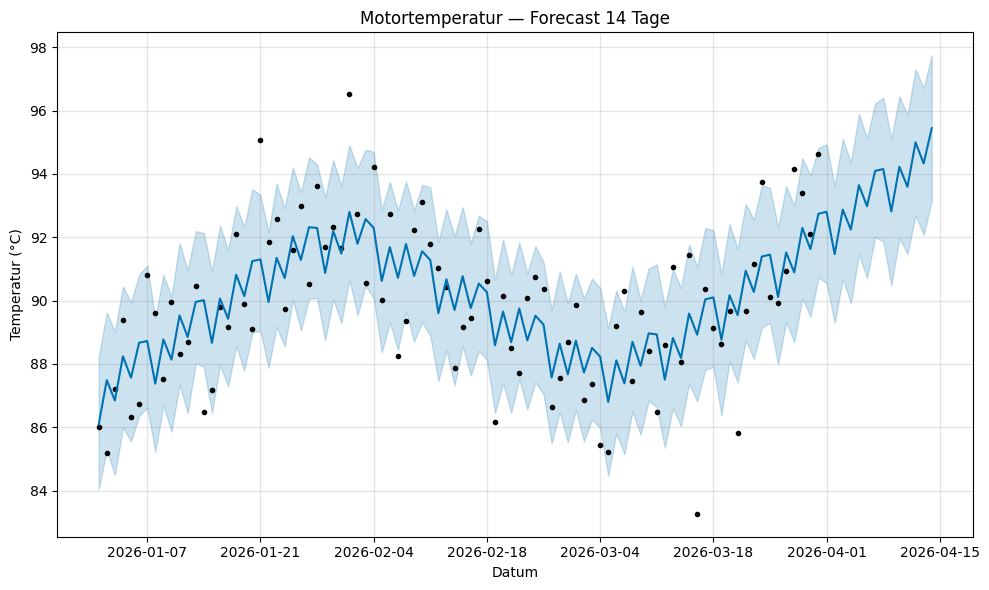

In [6]:
# Forecast plotten
fig = modell.plot(forecast)
plt.title("Motortemperatur — Forecast 14 Tage")
plt.xlabel("Datum")
plt.ylabel("Temperatur (°C)")
plt.tight_layout()
plt.show()

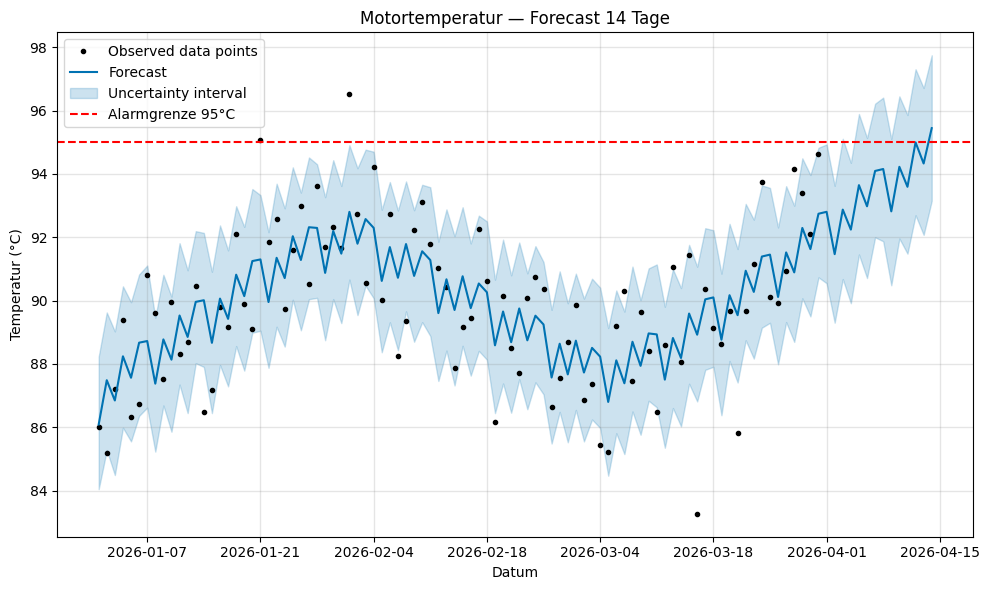

In [7]:
# Forecast mit Alarmgrenze
fig = modell.plot(forecast)
plt.axhline(y=95, color="red", linestyle="--", label="Alarmgrenze 95°C")
plt.title("Motortemperatur — Forecast 14 Tage")
plt.xlabel("Datum")
plt.ylabel("Temperatur (°C)")
plt.legend()
plt.tight_layout()
plt.show()

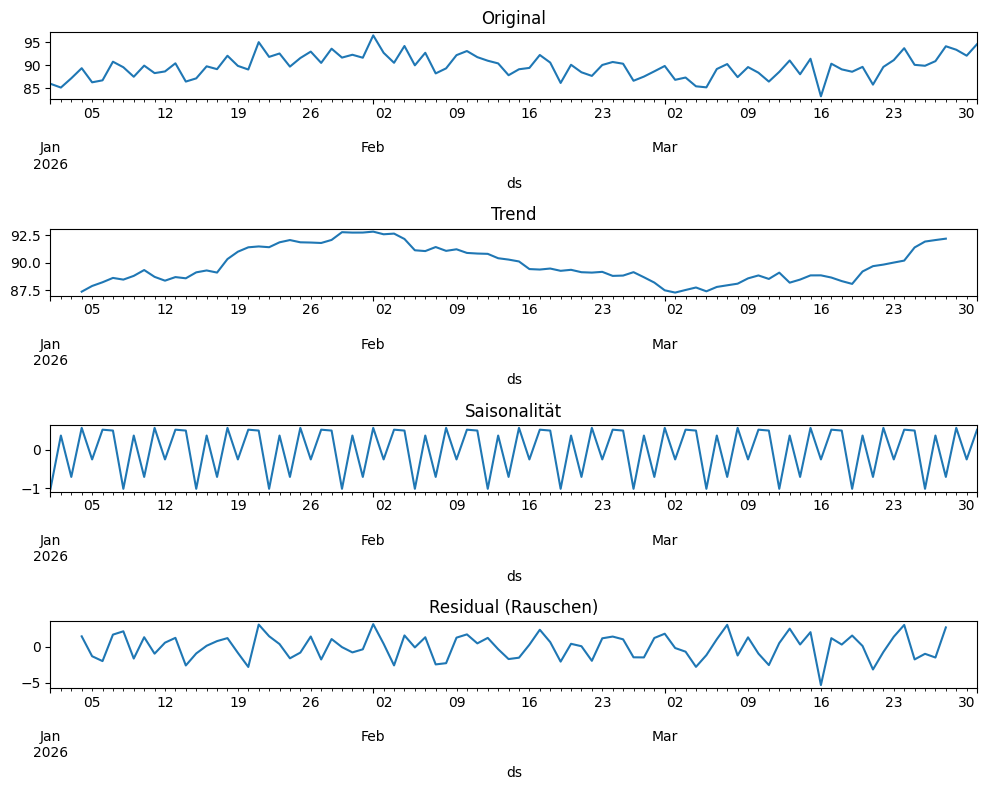

In [9]:
from statsmodels.tsa.seasonal import seasonal_decompose

# Zeitreihe zerlegen
df_indexed = df.set_index("ds")
result = seasonal_decompose(df_indexed["y"], model="additive", period=7)

# Plotten
fig, axes = plt.subplots(4, 1, figsize=(10, 8))
result.observed.plot(ax=axes[0], title="Original")
result.trend.plot(ax=axes[1], title="Trend")
result.seasonal.plot(ax=axes[2], title="Saisonalität")
result.resid.plot(ax=axes[3], title="Residual (Rauschen)")
plt.tight_layout()
plt.show()

In [10]:
# Anomalien im Residual finden
residual = result.resid.dropna()
mean = residual.mean()
std = residual.std()

anomalien = residual[abs(residual - mean) > 2 * std]
print(f"Gefundene Anomalien: {len(anomalien)}")
print(anomalien)

Gefundene Anomalien: 1
ds
2026-03-16   -5.33566
Name: resid, dtype: float64
